In [2]:
!pip install pandas numpy matplotlib seaborn

Defaulting to user installation because normal site-packages is not writeable


In [3]:
import pandas as pd

df = pd.read_csv("../data/raw/application_train.csv")

print(df.shape)

(307511, 122)


In [5]:
print("Shape:", df.shape)

print("\nData Types:")
print(df.dtypes.value_counts())

print("\nMissing Values:")
print(df.isnull().sum().sort_values(ascending=False).head(20))

Shape: (307511, 122)

Data Types:
float64    65
int64      41
object     16
Name: count, dtype: int64

Missing Values:
COMMONAREA_MEDI             214865
COMMONAREA_AVG              214865
COMMONAREA_MODE             214865
NONLIVINGAPARTMENTS_MODE    213514
NONLIVINGAPARTMENTS_AVG     213514
NONLIVINGAPARTMENTS_MEDI    213514
FONDKAPREMONT_MODE          210295
LIVINGAPARTMENTS_MODE       210199
LIVINGAPARTMENTS_AVG        210199
LIVINGAPARTMENTS_MEDI       210199
FLOORSMIN_AVG               208642
FLOORSMIN_MODE              208642
FLOORSMIN_MEDI              208642
YEARS_BUILD_MEDI            204488
YEARS_BUILD_MODE            204488
YEARS_BUILD_AVG             204488
OWN_CAR_AGE                 202929
LANDAREA_MEDI               182590
LANDAREA_MODE               182590
LANDAREA_AVG                182590
dtype: int64


In [6]:
df["TARGET"].value_counts()

TARGET
0    282686
1     24825
Name: count, dtype: int64

In [7]:
df["TARGET"].value_counts(normalize=True) * 100

TARGET
0    91.927118
1     8.072882
Name: proportion, dtype: float64

In [8]:
df["AGE"] = abs(df["DAYS_BIRTH"]) / 365

df["AGE"].describe()

count    307511.000000
mean         43.936973
std          11.956133
min          20.517808
25%          34.008219
50%          43.150685
75%          53.923288
max          69.120548
Name: AGE, dtype: float64

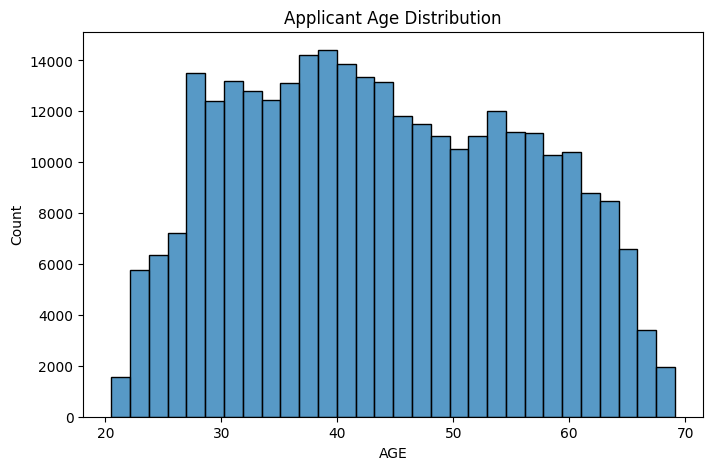

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df["AGE"], bins=30)
plt.title("Applicant Age Distribution")
plt.show()

In [10]:
gender_default = pd.crosstab(
    df["CODE_GENDER"],
    df["TARGET"],
    normalize="index"
) * 100

print(gender_default)

TARGET                0          1
CODE_GENDER                       
F             93.000672   6.999328
M             89.858080  10.141920
XNA          100.000000   0.000000


In [11]:
income_default = df.groupby("TARGET")["AMT_INCOME_TOTAL"].mean()

print(income_default)

TARGET
0    169077.722266
1    165611.760906
Name: AMT_INCOME_TOTAL, dtype: float64


In [12]:
education_default = pd.crosstab(
    df["NAME_EDUCATION_TYPE"],
    df["TARGET"],
    normalize="index"
) * 100

print(education_default)

TARGET                                 0          1
NAME_EDUCATION_TYPE                                
Academic degree                98.170732   1.829268
Higher education               94.644885   5.355115
Incomplete higher              91.515034   8.484966
Lower secondary                89.072327  10.927673
Secondary / secondary special  91.060071   8.939929


In [13]:
import joblib

model = joblib.load("../models/credit_risk_model.pkl")

print(type(model))

<class 'sklearn.pipeline.Pipeline'>
